In [1]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
query = """
SELECT *
FROM features.aisle_features
"""

aisle_df = pd.read_sql(query, engine)

aisle_df.shape

(134, 5)

In [4]:
aisle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   aisle             134 non-null    object 
 1   purchase_count    134 non-null    int64  
 2   unique_customers  134 non-null    int64  
 3   unique_products   134 non-null    int64  
 4   reorder_rate      134 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 5.4+ KB


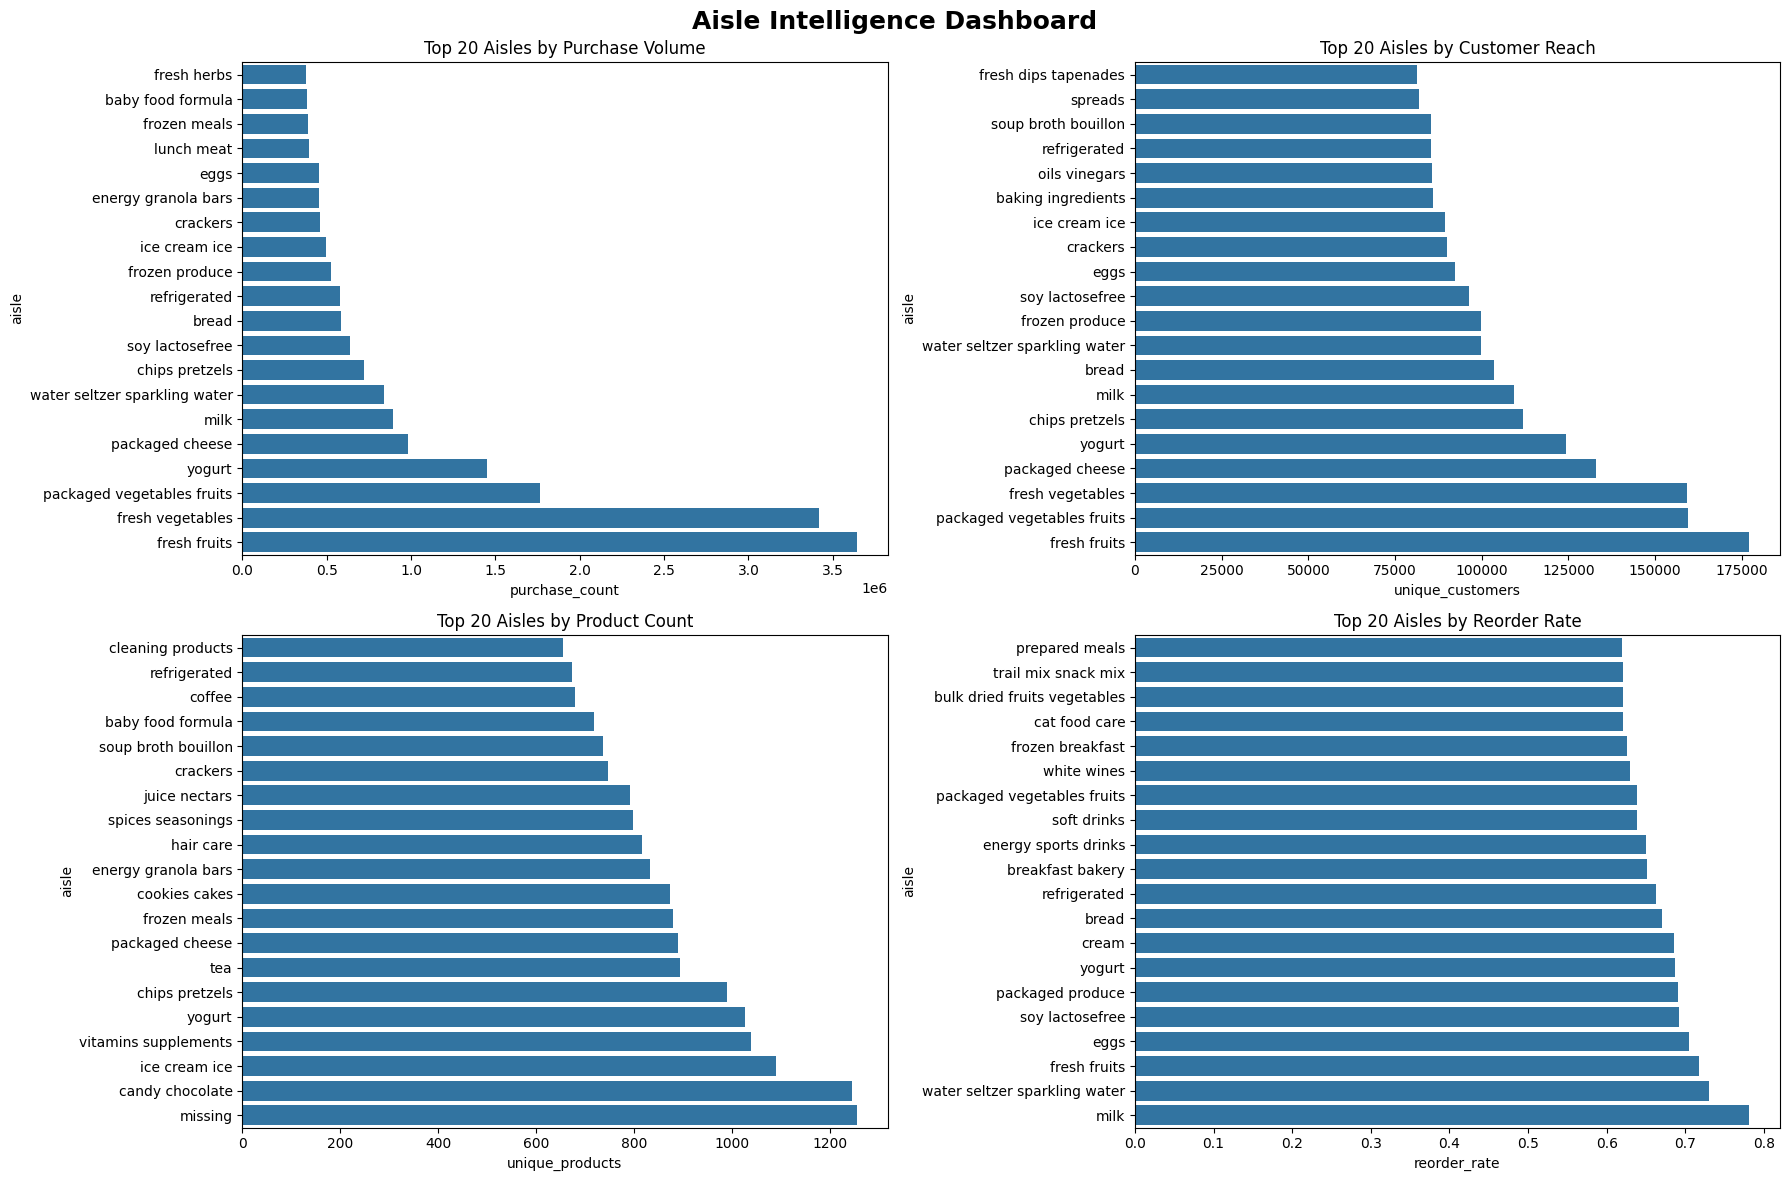

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

axes = axes.flatten()

# --------------------------------------------------
# 1. Top Aisles by Purchase Volume
# --------------------------------------------------

top_purchase = (
    aisle_df
    .nlargest(20, "purchase_count")
    .sort_values("purchase_count")
)

sns.barplot(
    data=top_purchase,
    x="purchase_count",
    y="aisle",
    ax=axes[0]
)

axes[0].set_title(
    "Top 20 Aisles by Purchase Volume"
)

# --------------------------------------------------
# 2. Top Aisles by Customer Reach
# --------------------------------------------------

top_customers = (
    aisle_df
    .nlargest(20, "unique_customers")
    .sort_values("unique_customers")
)

sns.barplot(
    data=top_customers,
    x="unique_customers",
    y="aisle",
    ax=axes[1]
)

axes[1].set_title(
    "Top 20 Aisles by Customer Reach"
)

# --------------------------------------------------
# 3. Top Aisles by Product Count
# --------------------------------------------------

top_products = (
    aisle_df
    .nlargest(20, "unique_products")
    .sort_values("unique_products")
)

sns.barplot(
    data=top_products,
    x="unique_products",
    y="aisle",
    ax=axes[2]
)

axes[2].set_title(
    "Top 20 Aisles by Product Count"
)

# --------------------------------------------------
# 4. Top Aisles by Reorder Rate
# --------------------------------------------------

top_reorder = (
    aisle_df
    .nlargest(20, "reorder_rate")
    .sort_values("reorder_rate")
)

sns.barplot(
    data=top_reorder,
    x="reorder_rate",
    y="aisle",
    ax=axes[3]
)

axes[3].set_title(
    "Top 20 Aisles by Reorder Rate"
)

plt.suptitle(
    "Aisle Intelligence Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Aisle Intelligence Analysis

The Aisle Intelligence Dashboard provides a detailed view of customer purchasing behavior across 134 aisles. Unlike department-level analysis, aisle-level insights capture specific shopping intents and product categories, making them highly valuable for recommendation systems and customer personalization.

---

## 1. Top Aisles by Purchase Volume

Purchase volume is concentrated within a small number of aisles.

### Top Performing Aisles

- Fresh Fruits
- Fresh Vegetables
- Packaged Vegetables Fruits
- Yogurt
- Packaged Cheese

### Key Insights

- Fresh produce dominates overall purchasing activity.
- Dairy-related aisles such as Yogurt and Packaged Cheese generate substantial demand.
- Healthy and frequently consumed products account for a large portion of purchases.

### Business Implications

- Fresh produce is the primary driver of customer engagement.
- Inventory planning should prioritize high-volume aisles.
- These aisles represent excellent candidates for recommendation placement and promotional campaigns.

---

## 2. Top Aisles by Customer Reach

Customer reach measures how many unique customers purchase from an aisle.

### Key Insights

- Fresh Fruits reaches the largest customer population.
- Fresh Vegetables and Packaged Vegetables Fruits also exhibit broad customer penetration.
- Dairy and snack-related aisles maintain strong customer reach.

### Business Implications

- These aisles represent universal shopping categories.
- Products within these aisles are likely to be relevant to a large portion of customers.
- Cross-selling strategies can leverage these high-reach categories.

---

## 3. Top Aisles by Product Count

Product count reflects catalog diversity.

### Key Insights

- Missing, Candy Chocolate, Ice Cream Ice, and Vitamins Supplements contain the largest number of products.
- High catalog size does not necessarily correspond to high purchase volume.
- Several highly purchased aisles contain relatively focused product assortments.

### Business Interpretation

Two aisle categories emerge:

#### Demand-Driven Aisles

- Fresh Fruits
- Fresh Vegetables
- Yogurt
- Packaged Cheese

These aisles generate high demand despite moderate catalog sizes.

#### Catalog-Driven Aisles

- Candy Chocolate
- Vitamins Supplements
- Ice Cream Ice

These aisles provide greater product variety but lower overall demand.

### Business Implications

- Product assortment alone does not guarantee purchasing activity.
- Customer demand is concentrated around a relatively small set of highly relevant categories.

---

## 4. Top Aisles by Reorder Rate

Reorder rate measures aisle-level customer loyalty.

### Highest Loyalty Aisles

- Milk
- Water Seltzer Sparkling Water
- Fresh Fruits
- Eggs
- Soy Lactosefree
- Packaged Produce
- Yogurt

### Key Insights

- Frequently consumed products dominate the highest reorder-rate aisles.
- These aisles represent recurring shopping needs rather than occasional purchases.
- Customers exhibit strong habitual behavior within these categories.

### Business Implications

- Replenishment recommendations should focus heavily on these aisles.
- Demand forecasting is likely to be highly reliable for these categories.
- Subscription-based purchasing experiences may perform well in these aisles.

---

# Overall Findings

The aisle-level analysis reveals three important patterns:

### 1. Fresh Produce Dominates Customer Behavior

Fresh Fruits and Fresh Vegetables lead both purchase volume and customer reach, making them the most important shopping categories on the platform.

### 2. Customer Demand Is Highly Concentrated

A relatively small number of aisles generate a disproportionate share of purchases and customer interactions.

### 3. Loyalty Is Strongest in Consumable Categories

Milk, Eggs, Yogurt, Water, and Fresh Produce demonstrate the highest reorder rates, reflecting predictable replenishment behavior.

---

# Comparison with Department Analysis

Department analysis identified broad categories such as Produce and Dairy & Eggs as key demand drivers.

Aisle analysis provides a more detailed understanding by revealing the specific categories responsible for that demand:

| Department | Key Aisles |
|------------|------------|
| Produce | Fresh Fruits, Fresh Vegetables |
| Dairy & Eggs | Milk, Yogurt, Packaged Cheese, Eggs |
| Beverages | Water Seltzer Sparkling Water |
| Snacks | Chips Pretzels, Crackers |

This additional granularity is particularly valuable for recommendation systems and personalized customer experiences.

---

# Conclusion

The Aisle Intelligence layer provides a detailed view of customer shopping intent and category preferences. Fresh produce, dairy products, and other consumable goods dominate both purchase activity and customer loyalty, highlighting their importance for inventory planning, demand forecasting, recommendation systems, and customer retention strategies.

These insights provide a strong foundation for category-level personalization and future recommendation engine development within the CommerceAI platform.